In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
df = pd.read_csv("10-diamonds.csv")

In [3]:
df


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [5]:
df.isna().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [6]:
## X Y Z Sİ 0 OLANLAR Bİ İŞİMİZE YARAMAZ 


df[df["x"]==0]
df[df["y"]==0]
df[df["y"]==0]


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
11963,11964,1.00,Very Good,H,VS2,63.3,53.0,5139,0.0,0.0,0.0
15951,15952,1.14,Fair,G,VS1,57.5,67.0,6381,0.0,0.0,0.0
24520,24521,1.56,Ideal,G,VS2,62.2,54.0,12800,0.0,0.0,0.0
26243,26244,1.20,Premium,D,VVS1,62.1,59.0,15686,0.0,0.0,0.0
27429,27430,2.25,Premium,H,SI2,62.8,59.0,18034,0.0,0.0,0.0
49556,49557,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.0,0.0
49557,49558,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.0,0.0


In [7]:
dfclean = df.copy()
dfclean= df.drop(df[df["y"]==0].index)
dfclean= df.drop(df[df["x"]==0].index)
dfclean= df.drop(df[df["z"]==0].index)

In [8]:
dfclean[dfclean["y"]==0]

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z


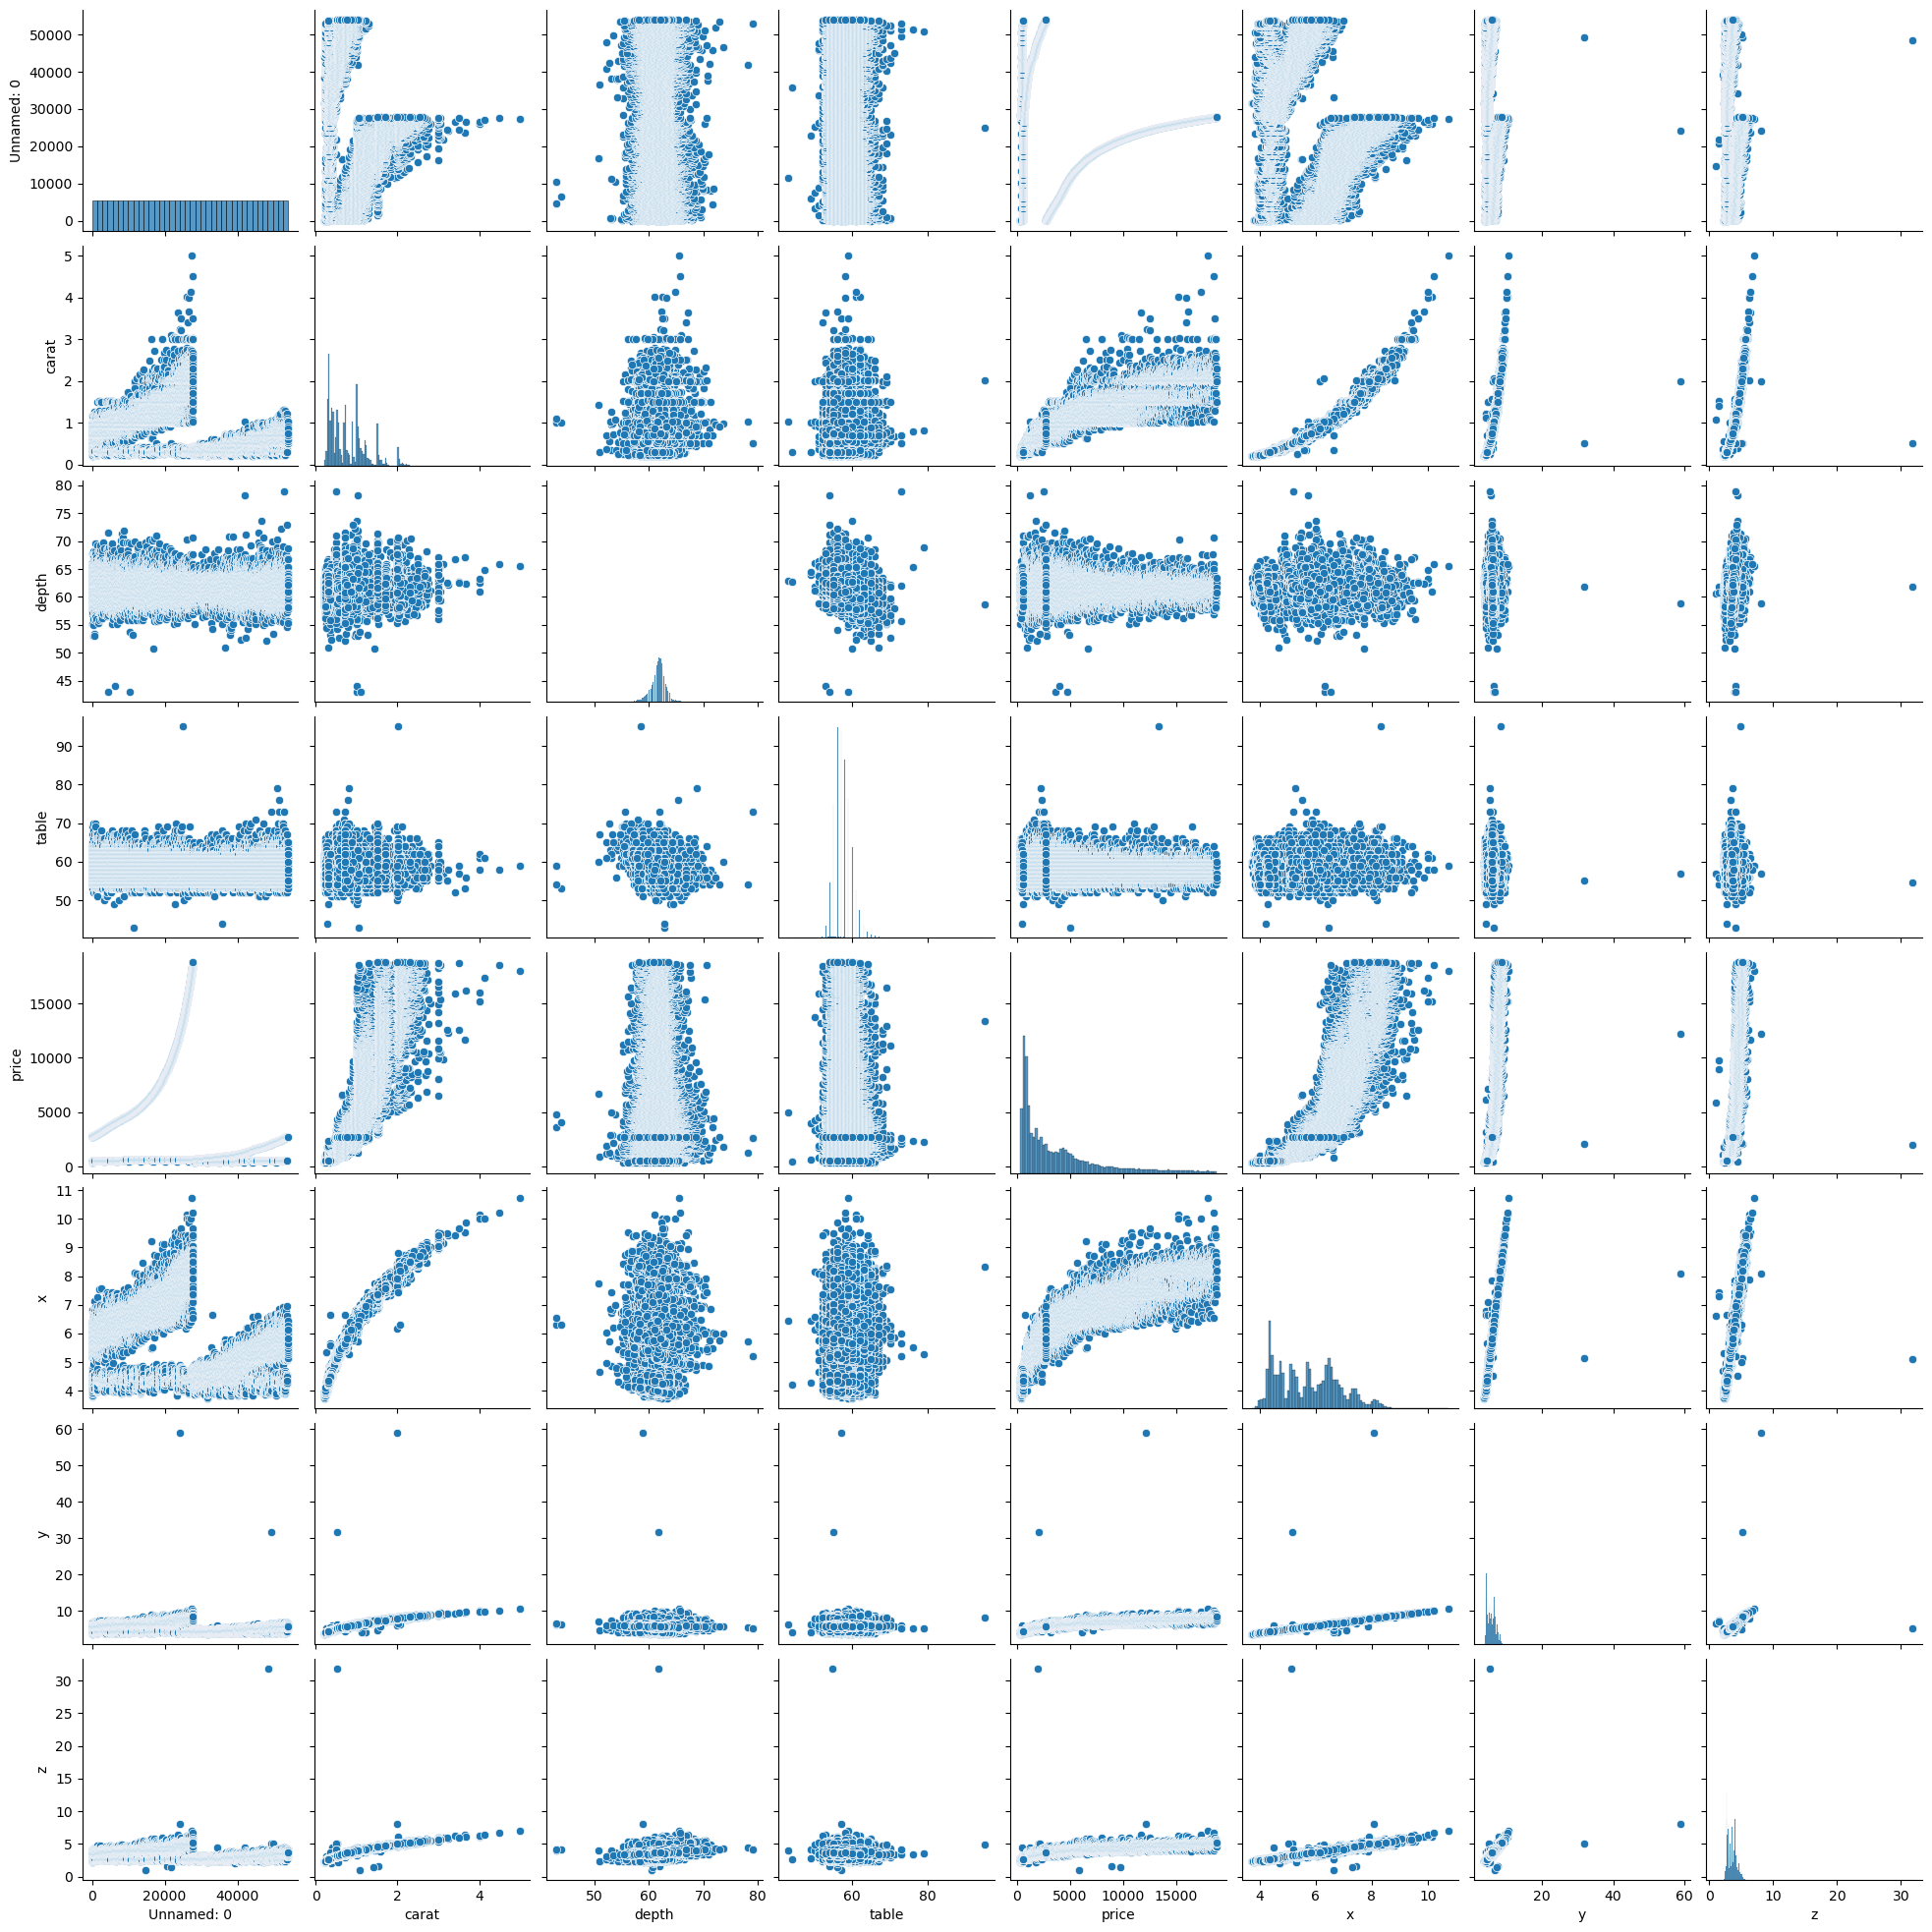

In [9]:
sns.pairplot(data=dfclean)

<Axes: xlabel='x', ylabel='price'>

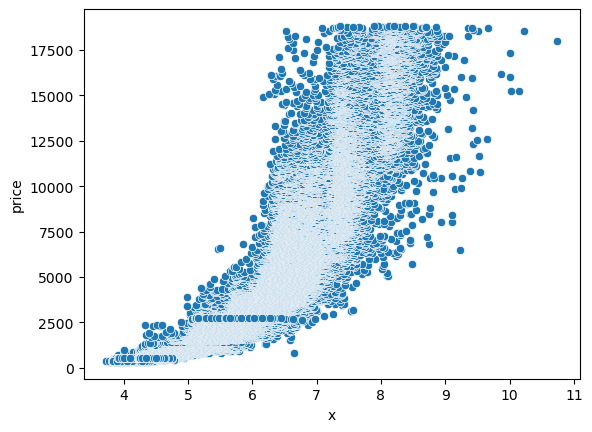

In [10]:
sns.scatterplot(x=dfclean["x"],y=dfclean["price"])

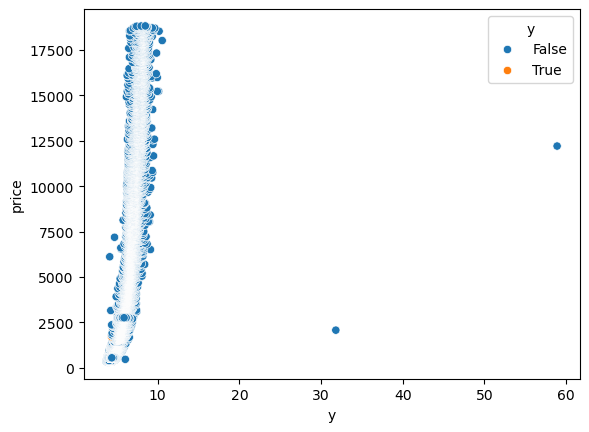

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Doğru Kullanım
sns.scatterplot(
    x=dfclean["y"], 
    y=dfclean["price"], 
    hue=(dfclean["y"] == 4.34) # Dikkat: Sadece koşulu yazdık, dfclean[...] içine almadık.
)

plt.show()


<Axes: xlabel='depth', ylabel='price'>

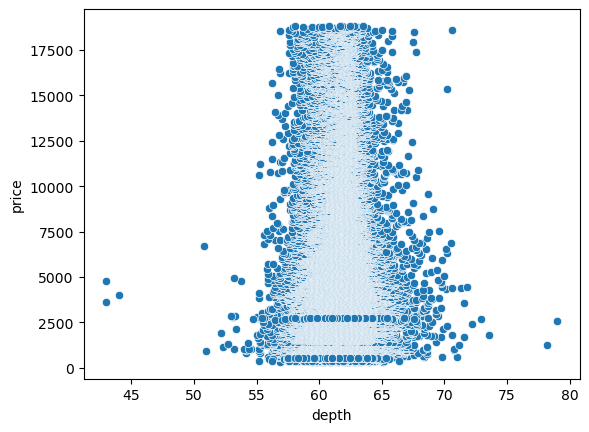

In [12]:
sns.scatterplot(x=dfclean["depth"],y=dfclean["price"])

In [13]:
(dfclean[(dfclean["depth"]<75) & (dfclean["depth"]>45)])

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [14]:
len(dfclean["depth"])

53920

In [18]:
# there are some outliers over here as well, just by looking at the graphs we can eliminate outliers easily
dfclean = dfclean[(dfclean["depth"]<75)&(dfclean["depth"]>45)]
dfclean = dfclean[(dfclean["table"]<80)&(dfclean["table"]>40)]
dfclean = dfclean[(dfclean["y"]<30)]
dfclean = dfclean[(dfclean["z"]<30)&(dfclean["z"]>2)]

In [19]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [20]:
dfclean.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000
mean,26971.950804,0.797628,61.749741,57.455948,3930.584470,5.731463,5.733292,3.539441
std,15570.790852,0.473765,1.420119,2.226153,3987.202815,1.119384,1.111252,0.691434
min,1.000000,0.200000,50.800000,43.000000,326.000000,3.730000,3.680000,2.060000
25%,13487.500000,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,26975.000000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.500000,1.040000,62.500000,59.000000,5322.000000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,73.600000,79.000000,18823.000000,10.740000,10.540000,6.980000


In [21]:
dfclean.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [24]:
dfclean=dfclean.drop(labels="Unnamed: 0",axis=1)

In [25]:
dfclean.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


<Axes: xlabel='y', ylabel='price'>

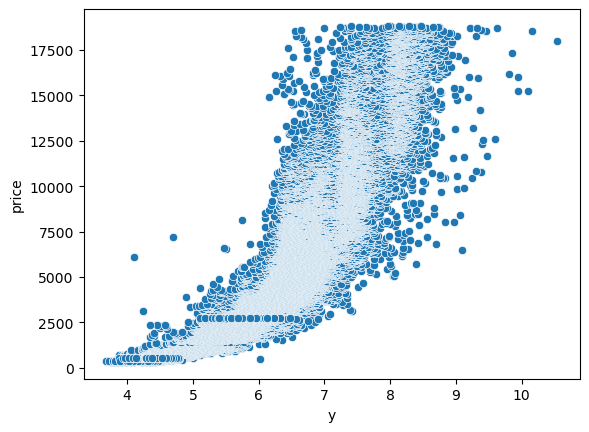

In [29]:
sns.scatterplot(x=dfclean["y"],y=dfclean["price"])

<Axes: xlabel='z', ylabel='price'>

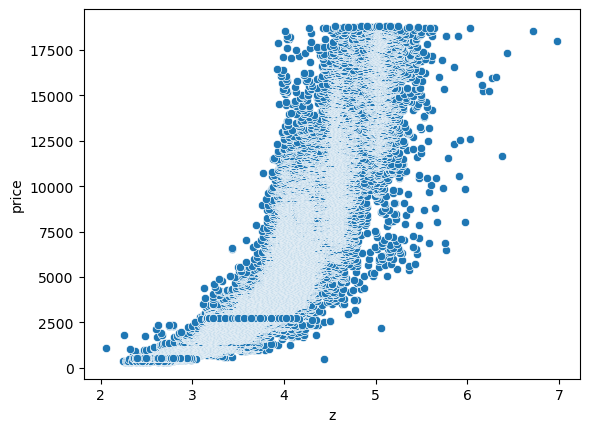

In [31]:
sns.scatterplot(x=dfclean["z"],y=dfclean["price"])

In [32]:
dfclean.describe()

,carat,depth,table,price,x,y,z
count,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000
mean,0.797628,61.749741,57.455948,3930.584470,5.731463,5.733292,3.539441
std,0.473765,1.420119,2.226153,3987.202815,1.119384,1.111252,0.691434
min,0.200000,50.800000,43.000000,326.000000,3.730000,3.680000,2.060000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5322.000000,6.540000,6.540000,4.040000
max,5.010000,73.600000,79.000000,18823.000000,10.740000,10.540000,6.980000


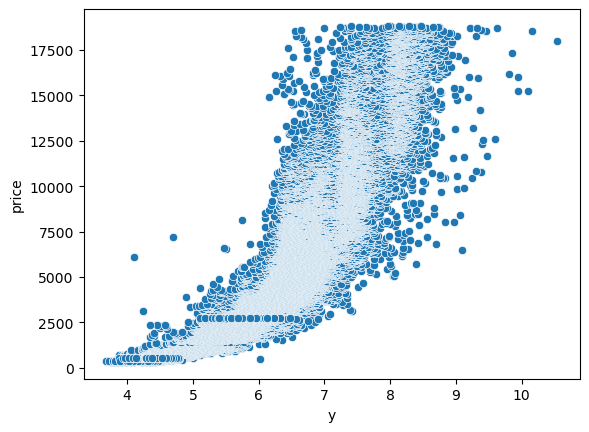

In [34]:
dfclean.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [37]:
dfclean["cut"].value_counts()

cut
Ideal        21543
Premium      13779
Very Good    12080
Good          4902
Fair          1603
Name: count, dtype: int64

In [38]:
dfclean["clarity"].value_counts()

clarity
SI1     13059
VS2     12250
SI2      9184
VS1      8167
VVS2     5066
VVS1     3654
IF       1790
I1        737
Name: count, dtype: int64

In [39]:
dfclean["color"].value_counts()

color
G    11282
E     9792
F     9536
H     8296
D     6774
I     5420
J     2807
Name: count, dtype: int64

In [40]:
X = dfclean.drop(labels="price",axis=1)
y = dfclean["price"]

In [41]:
from sklearn.model_selection import train_test_split

X_train , X_test ,y_train ,y_test = train_test_split(X,y,train_size=0.8,random_state=42)

In [44]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

In [47]:
for col in ["cut","color","clarity"]:
    X_train[col] = labelencoder.fit_transform(X_train[col])
    X_test[col] = labelencoder.transform(X_test[col])

In [50]:
dfclean["cut"].value_counts()

cut
Ideal        21543
Premium      13779
Very Good    12080
Good          4902
Fair          1603
Name: count, dtype: int64

In [51]:
dfclean["color"].value_counts()

color
G    11282
E     9792
F     9536
H     8296
D     6774
I     5420
J     2807
Name: count, dtype: int64

In [52]:
dfclean["clarity"].value_counts()

clarity
SI1     13059
VS2     12250
SI2      9184
VS1      8167
VVS2     5066
VVS1     3654
IF       1790
I1        737
Name: count, dtype: int64

In [53]:
X_train["cut"].value_counts()

cut
2    17192
3    11077
4     9680
1     3910
0     1266
Name: count, dtype: int64

In [56]:
for col in ["cut","color","clarity"]:
    print(X_train[col].unique())

[2 3 4 1 0]
[4 0 1 6 2 3 5]
[2 5 4 7 6 3 1 0]


In [57]:
X_train.describe()

,carat,cut,color,clarity,depth,table,x,y,z
count,43125.000000,43125.000000,43125.000000,43125.000000,43125.000000,43125.000000,43125.000000,43125.000000,43125.000000
mean,0.799158,2.556406,2.582817,3.834041,61.745472,57.455061,5.734669,5.736452,3.541114
std,0.475581,1.026276,1.700321,1.723738,1.416186,2.225739,1.122620,1.114371,0.692998
min,0.200000,0.000000,0.000000,0.000000,50.800000,44.000000,3.730000,3.680000,2.060000
25%,0.400000,2.000000,1.000000,2.000000,61.000000,56.000000,4.710000,4.720000,2.910000
50%,0.700000,2.000000,3.000000,4.000000,61.800000,57.000000,5.700000,5.710000,3.530000
75%,1.040000,3.000000,4.000000,5.000000,62.500000,59.000000,6.540000,6.540000,4.040000
max,5.010000,4.000000,6.000000,7.000000,73.600000,79.000000,10.740000,10.540000,6.980000


In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_absolute_error ,mean_squared_error

linear = LinearRegression()

853.7813710659364
1756602.8420336081
0.8843404413330286


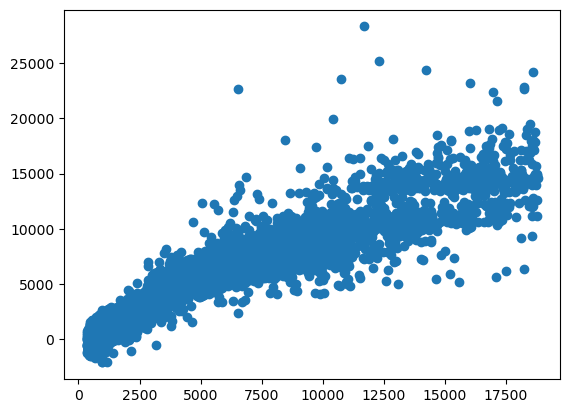

In [66]:
linear.fit(X_train_scaled,y_train)
y_pred = linear.predict(X_test_scaled)
mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
mse = mean_squared_error(y_true=y_test,y_pred=y_pred)
r2_s= r2_score(y_true=y_test,y_pred=y_pred)
print(mae)
print(mse)
print(r2_s)
plt.scatter(y=y_pred,x=y_test)
plt.show()

1304.6714563459795
7218910.412097895
0.5246870992460382


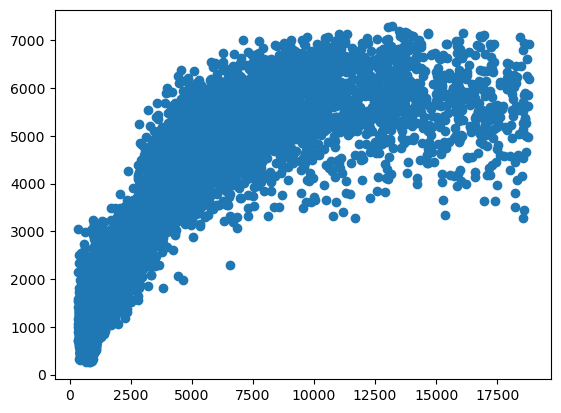

In [68]:
from sklearn.svm import SVR 
svr = SVR()
svr.fit(X_train_scaled,y_train)
y_pred = svr.predict(X_test_scaled)
mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
mse = mean_squared_error(y_true=y_test,y_pred=y_pred)
r2_s= r2_score(y_true=y_test,y_pred=y_pred)
print(mae)
print(mse)
print(r2_s)
plt.scatter(y=y_pred,x=y_test)
plt.show()

In [69]:
## HYPERPARAMETRE TUNİNG 

In [73]:
paramgrid= {
    "C": [0.1,2,5,10,100,1000]
    ,
    "gamma": [1,0.1,0.001]
    ,
    "kernel": ["rbf","linear"]
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=SVR(),param_grid=paramgrid,n_jobs=-1,verbose = 3,)

grid.fit(X_train_scaled,y_train)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [ ]:
y_pred = grid.predict(X_test_scaled)
mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
mse = mean_squared_error(y_true=y_test,y_pred=y_pred)
r2_s= r2_score(y_true=y_test,y_pred=y_pred)
print(mae)
print(mse)
print(r2_s)
plt.scatter(y=y_pred,x=y_test)
plt.show()